In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Check if the GPU is enabled.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


In [ ]:
# Convert the images into Tensor matrices for visualization
transform_eda = transforms.Compose([
    transforms.ToTensor()
])

# Download and load the Training set
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_eda)

# Download and load the Test set
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_eda)

# Define the 10 classes of the CIFAR-10 dataset
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# Print the size of the datasets to verify
print(f"Number of training images: {len(trainset)}")
print(f"Number of test images: {len(testset)}")

100%|██████████| 170M/170M [00:12<00:00, 13.2MB/s]


Number of training images: 50000
Number of test images: 10000


In [ ]:
# Wrap the training dataset in a DataLoader
# batch_size=16 means the model will process 16 images at a time
trainloader_eda = torch.utils.data.DataLoader(trainset, batch_size=16,
                                              shuffle=True, num_workers=2)

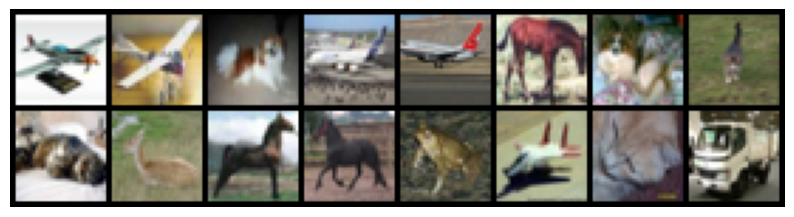

GroundTruth:  plane    | plane    | dog      | plane    | plane    | horse    | dog      | cat      | cat      | deer     | horse    | horse    | frog     | plane    | cat      | truck   


In [ ]:
# Function to display an image from a PyTorch Tensor
def imshow(img):
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))

    # PyTorch uses (Channels, Height, Width) format
    # Matplotlib requires (Height, Width, Channels) format, so we transpose it
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Get a random batch of 16 images and their labels from the training set
dataiter = iter(trainloader_eda)
images, labels = next(dataiter)

# Display the images in a grid (2 rows, 8 columns)
imshow(torchvision.utils.make_grid(images, nrow=8))

# Print the corresponding ground truth labels
print('GroundTruth: ', ' | '.join(f'{classes[labels[j]]:8s}' for j in range(16)))

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# ==========================================
# 1. DATA AUGMENTATION & NORMALIZATION
# ==========================================
# Define transformations for the training set with augmentation
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),    # Randomly flip images left-right
    transforms.RandomCrop(32, padding=4), # Randomly crop images with padding
    transforms.ToTensor(),                # Convert to Tensor
    # Normalize with standard CIFAR-10 mean and standard deviation
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Define transformations for the test set (NO augmentation, only normalization)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Reload the datasets with the new transforms
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Update DataLoaders with a larger batch size for actual training (e.g., 128)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

# ==========================================
# 2. LOAD PRE-TRAINED CNN (RESNET-18)
# ==========================================
# Load ResNet-18 with pre-trained weights from ImageNet
cnn_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# The original ResNet-18 outputs 1000 classes. We need to modify the final Fully Connected (fc) layer for 10 classes.
num_ftrs = cnn_model.fc.in_features
cnn_model.fc = nn.Linear(num_ftrs, 10) # 10 is the number of classes in CIFAR-10

# Move the model to the GPU (cuda)
cnn_model = cnn_model.to(device)

# ==========================================
# 3. DEFINE LOSS FUNCTION AND OPTIMIZER
# ==========================================
# CrossEntropyLoss is standard for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer with a learning rate of 0.001
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

print("ResNet-18 has been successfully configured for CIFAR-10 and loaded to GPU!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 202MB/s]


ResNet-18 has been successfully configured for CIFAR-10 and loaded to GPU!


In [ ]:
import time

# Number of epochs (full passes through the dataset)
# Start with 5 for quick testing. Increase to 10-20 later for better accuracy.
num_epochs = 5

# Lists to store metrics for plotting later (very useful for your report)
train_losses = []
test_accuracies = []

print(f"Starting Training Loop for {num_epochs} epochs...")
start_time = time.time()

for epoch in range(num_epochs):
    # ==========================================
    # 1. TRAINING PHASE
    # ==========================================
    cnn_model.train() # Set model to training mode (enables Dropout, BatchNorm)
    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        # Get the inputs and labels, move them to the GPU
        inputs, labels = data[0].to(device), data[1].to(device)

        # Zero the parameter gradients to avoid accumulation
        optimizer.zero_grad()

        # Forward pass: compute predicted outputs by passing inputs to the model
        outputs = cnn_model(inputs)

        # Calculate the loss
        loss = criterion(outputs, labels)

        # Backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()

        # Perform a single optimization step (parameter update)
        optimizer.step()

        # Accumulate the loss
        running_loss += loss.item()

    # Calculate average training loss for this epoch
    avg_train_loss = running_loss / len(trainloader)
    train_losses.append(avg_train_loss)

    # ==========================================
    # 2. EVALUATION PHASE (on Test Set)
    # ==========================================
    cnn_model.eval() # Set model to evaluation mode (disables Dropout, BatchNorm)
    correct = 0
    total = 0

    # Disable gradient calculation for faster computation and less memory usage
    with torch.no_grad():
        for data in testloader:
            inputs, labels = data[0].to(device), data[1].to(device)

            # Forward pass
            outputs = cnn_model(inputs)

            # The class with the highest energy is what we choose as prediction
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Calculate test accuracy for this epoch
    test_acc = 100 * correct / total
    test_accuracies.append(test_acc)

    # Print statistics for the current epoch
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} - Test Accuracy: {test_acc:.2f}%")

end_time = time.time()
print(f"Finished Training in {(end_time - start_time)/60:.2f} minutes!")

Starting Training Loop for 5 epochs...
Epoch [1/5] - Train Loss: 1.0525 - Test Accuracy: 73.50%
Epoch [2/5] - Train Loss: 0.7490 - Test Accuracy: 73.09%
Epoch [3/5] - Train Loss: 0.6538 - Test Accuracy: 78.84%
Epoch [4/5] - Train Loss: 0.5995 - Test Accuracy: 79.35%
Epoch [5/5] - Train Loss: 0.5598 - Test Accuracy: 78.98%
Finished Training in 2.41 minutes!


✅ Weight saved!


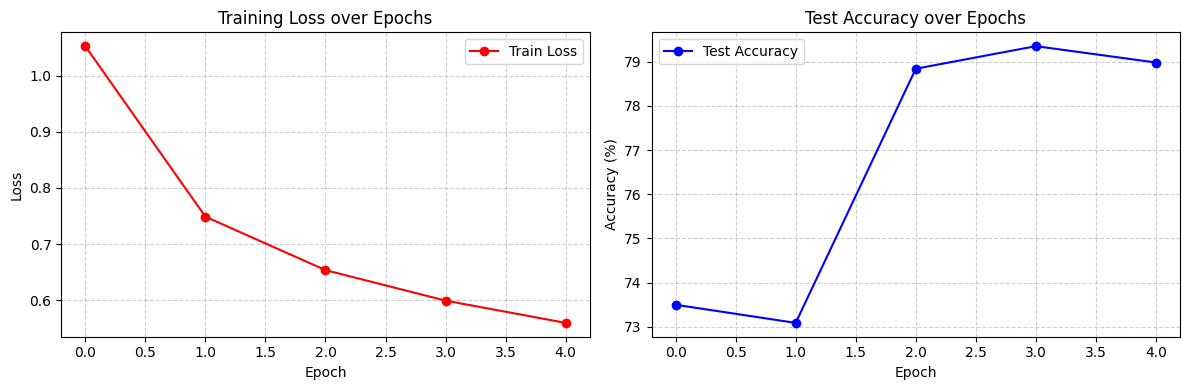


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       plane       0.79      0.69      0.73      1000
         car       0.85      0.92      0.89      1000
        bird       0.79      0.73      0.76      1000
         cat       0.66      0.62      0.64      1000
        deer       0.77      0.81      0.79      1000
         dog       0.75      0.70      0.73      1000
        frog       0.93      0.76      0.84      1000
       horse       0.80      0.87      0.83      1000
        ship       0.75      0.91      0.82      1000
       truck       0.83      0.90      0.86      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000



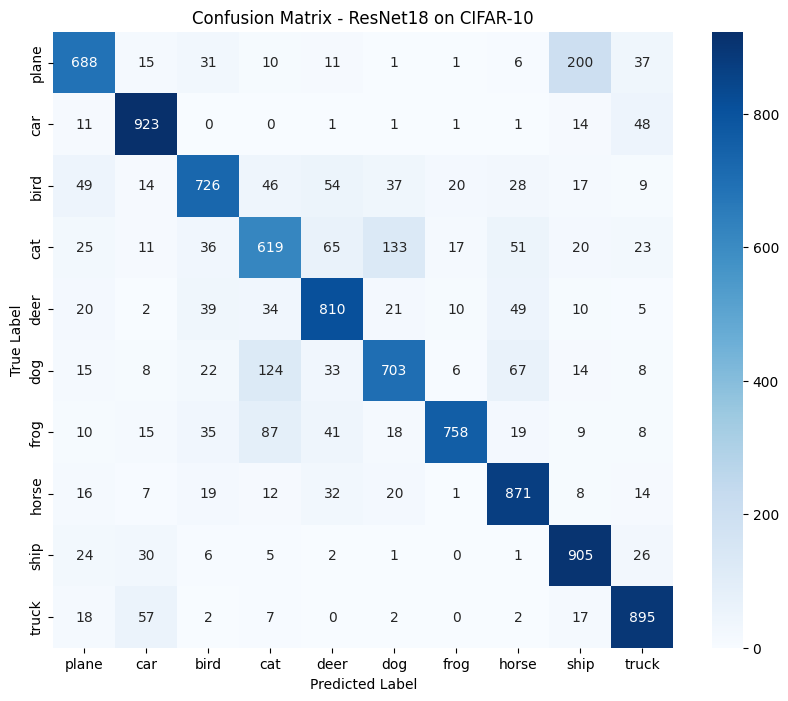

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ==========================================
# 1. LƯU MÔ HÌNH
# ==========================================
# Save the model weights so you don't have to retrain later
torch.save(cnn_model.state_dict(), 'resnet18_cifar10_epoch5.pth')
print("✅ Weight saved!")

# ==========================================
# 2. VẼ BIỂU ĐỒ LOSS VÀ ACCURACY
# ==========================================
plt.figure(figsize=(12, 4))

# Plot Training Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='red', marker='o')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Plot Test Accuracy
plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy', color='blue', marker='o')
plt.title('Test Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 3. TÍNH F1-SCORE VÀ MA TRẬN NHẦM LẪN
# ==========================================
cnn_model.eval()
all_preds = []
all_labels = []

# Gather all predictions on the test set
with torch.no_grad():
    for data in testloader:
        inputs, labels = data[0].to(device), data[1].to(device)
        outputs = cnn_model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Print the Classification Report (contains F1-scores)
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=classes))

# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - ResNet18 on CIFAR-10')
plt.show()

In [ ]:
# ==========================================
# 1. DATA AUGMENTATION CHO VIT (BẮT BUỘC RESIZE)
# ==========================================
# ViT requires input images to be 224x224 to split them into 16x16 patches.
transform_train_vit = transforms.Compose([
    transforms.Resize(224),               # Phóng to ảnh từ 32x32 lên 224x224
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test_vit = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Load datasets again with new ViT transforms
trainset_vit = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train_vit)
testset_vit = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test_vit)

# CRITICAL: Reduce batch_size to 64 (or 32).
# 224x224 images take up much more GPU memory. If it's too high, Colab will crash (Out of Memory).
trainloader_vit = torch.utils.data.DataLoader(trainset_vit, batch_size=64, shuffle=True, num_workers=2)
testloader_vit = torch.utils.data.DataLoader(testset_vit, batch_size=64, shuffle=False, num_workers=2)


# ==========================================
# 2. TẢI MÔ HÌNH PRE-TRAINED VIT-B_16
# ==========================================
print("Loading the ViT-B_16 model")
vit_model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

# Modify the final classification head
# In torchvision's ViT, the final layer is called 'heads.head' instead of 'fc'
num_ftrs_vit = vit_model.heads.head.in_features
vit_model.heads.head = nn.Linear(num_ftrs_vit, 10)

# Move ViT to GPU
vit_model = vit_model.to(device)


# ==========================================
# 3. LOSS FUNCTION & OPTIMIZER CHO VIT
# ==========================================
criterion_vit = nn.CrossEntropyLoss()

# Use a smaller Learning Rate for ViT (e.g., 1e-4) to avoid disrupting pre-trained weights
optimizer_vit = optim.Adam(vit_model.parameters(), lr=0.0001)

print("✅ ViT-B_16 has been successfully configured!")

Loading the ViT-B_16 model
✅ ViT-B_16 has been successfully configured!


In [ ]:
import time
from tqdm import tqdm # Thư viện tạo thanh tiến trình cực xịn của Python

num_epochs_vit = 5
train_losses_vit = []
test_accuracies_vit = []

print(f"Starting Training Loop for ViT-B_16 for {num_epochs_vit} epochs...")

for epoch in range(num_epochs_vit):
    # ==========================================
    # 1. TRAINING PHASE
    # ==========================================
    vit_model.train()
    running_loss = 0.0

    # Bọc trainloader bằng tqdm để hiện thanh tiến trình
    train_bar = tqdm(trainloader_vit, desc=f'Epoch {epoch+1}/{num_epochs_vit} [Train]')

    for inputs, labels in train_bar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_vit.zero_grad()
        outputs = vit_model(inputs)
        loss = criterion_vit(outputs, labels)

        loss.backward()
        optimizer_vit.step()

        running_loss += loss.item()

        # Cập nhật thông số loss real-time lên thanh tiến trình
        train_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = running_loss / len(trainloader_vit)
    train_losses_vit.append(avg_train_loss)

    # ==========================================
    # 2. EVALUATION PHASE
    # ==========================================
    vit_model.eval()
    correct = 0
    total = 0

    # Hiện thanh tiến trình cho cả lúc test
    test_bar = tqdm(testloader_vit, desc=f'Epoch {epoch+1}/{num_epochs_vit} [Test ]')

    with torch.no_grad():
        for inputs, labels in test_bar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = vit_model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_acc = 100 * correct / total
    test_accuracies_vit.append(test_acc)

    print(f"\n=> Kết quả Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Test Acc: {test_acc:.2f}%\n")

print("Hoàn tất huấn luyện ViT!")

Starting Training Loop for ViT-B_16 for 5 epochs...


Epoch 1/5 [Test ]: 100%|██████████| 157/157 [02:06<00:00,  1.24it/s]



=> Kết quả Epoch 1: Train Loss: 0.1037 | Test Acc: 94.54%



Epoch 2/5 [Test ]: 100%|██████████| 157/157 [02:06<00:00,  1.24it/s]



=> Kết quả Epoch 2: Train Loss: 0.0752 | Test Acc: 95.65%



...


=> Kết quả Epoch 3: Train Loss: 0.0678 | Test Acc: 94.91%



Epoch 4/5 [Test ]: 100%|██████████| 157/157 [01:59<00:00,  1.32it/s]



=> Kết quả Epoch 4: Train Loss: 0.0517 | Test Acc: 94.89%



Epoch 5/5 [Test ]: 100%|██████████| 157/157 [02:00<00:00,  1.30it/s]


=> Kết quả Epoch 5: Train Loss: 0.0452 | Test Acc: 95.54%

Hoàn tất huấn luyện ViT!


Mounted at /content/drive
✅ Đã lưu trọng số ViT an toàn tại: /content/drive/MyDrive/vit_b16_cifar10_epoch5.pth


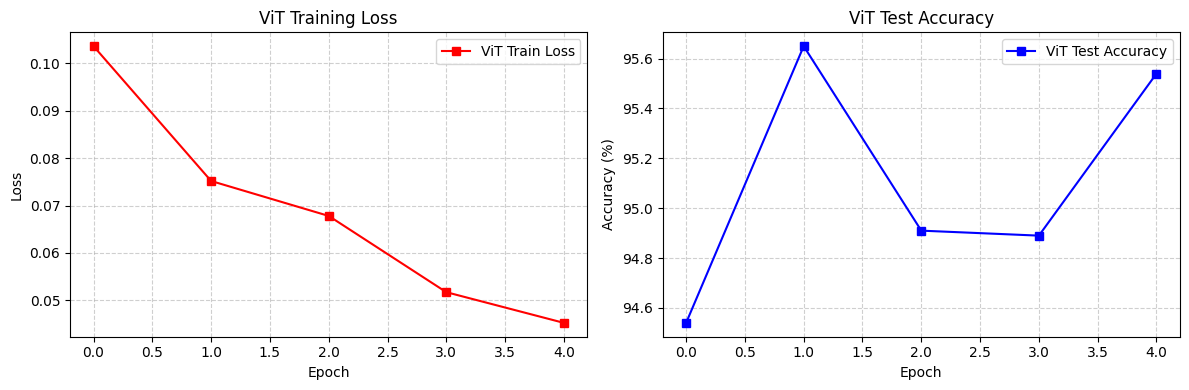

Đang chạy tập Test để tính F1-Score (Sẽ mất khoảng 2 phút)...

BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) - VIT
              precision    recall  f1-score   support

       plane       0.95      0.96      0.96      1000
         car       0.97      0.97      0.97      1000
        bird       0.97      0.94      0.95      1000
         cat       0.89      0.93      0.91      1000
        deer       0.97      0.96      0.97      1000
         dog       0.94      0.90      0.92      1000
        frog       0.94      0.99      0.97      1000
       horse       0.98      0.97      0.97      1000
        ship       0.96      0.97      0.97      1000
       truck       0.98      0.95      0.97      1000

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



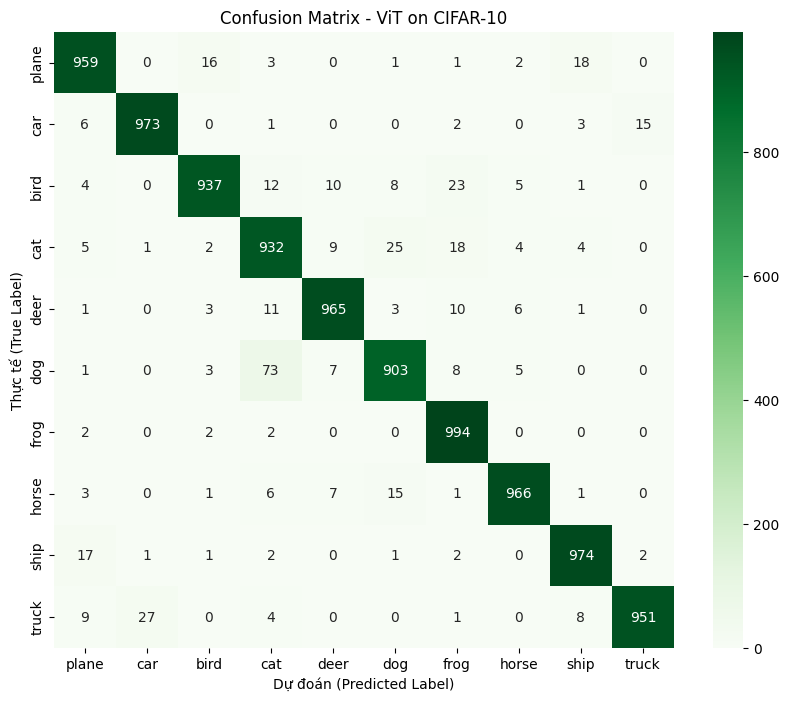

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import drive

# ==========================================
# 1. KẾT NỐI DRIVE & LƯU MÔ HÌNH
# ==========================================
drive.mount('/content/drive')
save_path_vit = '/content/drive/MyDrive/vit_b16_cifar10_epoch5.pth'
torch.save(vit_model.state_dict(), save_path_vit)
print(f"✅ Đã lưu trọng số ViT an toàn tại: {save_path_vit}")

# ==========================================
# 2. VẼ BIỂU ĐỒ LOSS VÀ ACCURACY CHO VIT
# ==========================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses_vit, label='ViT Train Loss', color='red', marker='s')
plt.title('ViT Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_accuracies_vit, label='ViT Test Accuracy', color='blue', marker='s')
plt.title('ViT Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 3. TÍNH F1-SCORE VÀ MA TRẬN NHẦM LẪN
# ==========================================
vit_model.eval()
all_preds_vit = []
all_labels_vit = []

print("Đang chạy tập Test để tính F1-Score (Sẽ mất khoảng 2 phút)...")
with torch.no_grad():
    for inputs, labels in testloader_vit:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = vit_model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds_vit.extend(predicted.cpu().numpy())
        all_labels_vit.extend(labels.cpu().numpy())

print("\n" + "="*50)
print("BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT) - VIT")
print("="*50)
print(classification_report(all_labels_vit, all_preds_vit, target_names=classes))

cm_vit = confusion_matrix(all_labels_vit, all_preds_vit)
plt.figure(figsize=(10, 8))
# Dùng tông màu Xanh lá (Greens) để phân biệt với biểu đồ màu Xanh dương của CNN lúc nãy
sns.heatmap(cm_vit, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
plt.xlabel('Dự đoán (Predicted Label)')
plt.ylabel('Thực tế (True Label)')
plt.title('Confusion Matrix - ViT on CIFAR-10')
plt.show()

100%|██████████| 170M/170M [00:05<00:00, 28.6MB/s]


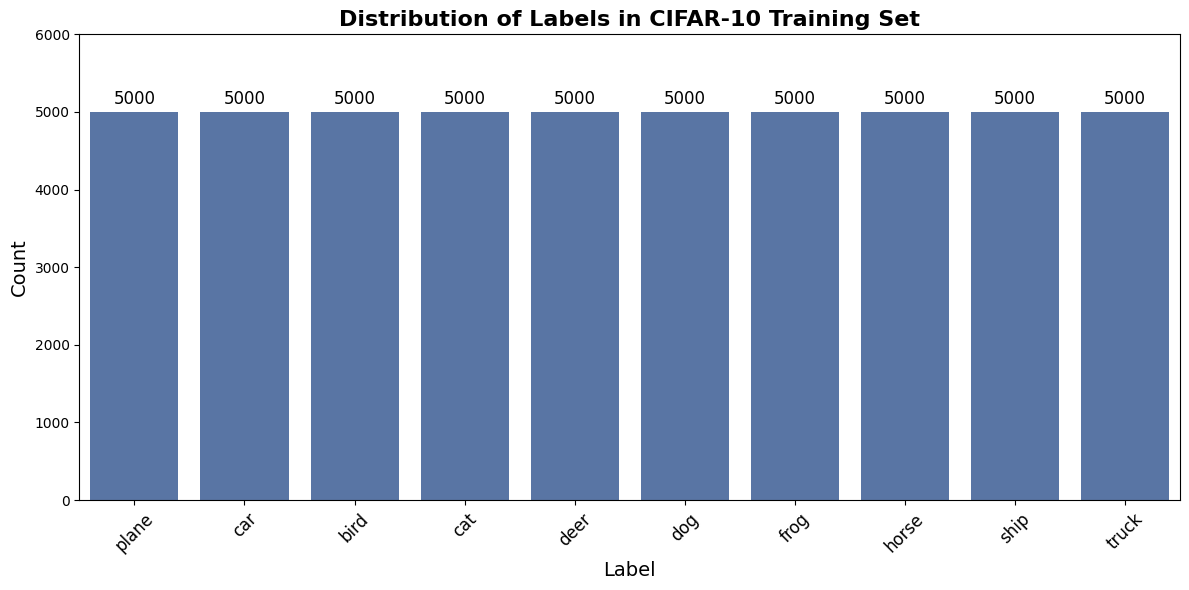

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torchvision

# Tải nhanh tập train để lấy nhãn (targets)
trainset_eda = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Đếm số lượng ảnh của mỗi lớp
targets = np.array(trainset_eda.targets)
counts = [np.sum(targets == i) for i in range(10)]

# Vẽ biểu đồ Bar Chart
plt.figure(figsize=(12, 6))
# Sử dụng dải màu xanh dương (tương đồng với biểu đồ phần Text của bạn)
sns.barplot(x=classes, y=counts, color='#4C72B0')

plt.title('Distribution of Labels in CIFAR-10 Training Set', fontsize=16, fontweight='bold')
plt.xlabel('Label', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.ylim(0, 6000) # Đẩy trục Y lên một chút để có chỗ viết số

# Ghi số 5000 lên đầu mỗi cột
for i, count in enumerate(counts):
    plt.text(i, count + 100, str(count), ha='center', fontsize=12)

plt.tight_layout()
plt.show()